In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import cv2
import easyocr
import matplotlib.pyplot as plt
import os

In [2]:
reader = easyocr.Reader(['en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


In [3]:
def preprocess_image(image_path):

    image = cv2.imread(image_path)

    if image is None:
        print("Image not found!")
        return None, None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)

    return image, gray

In [4]:
def extract_text(image):

    results = reader.readtext(image)

    extracted_text = ""

    for item in results:
        extracted_text += item[1] + "\n"

    return extracted_text, results

In [5]:
def ocr_document(image_path):

    # Preprocess image
    original, processed = preprocess_image(image_path)

    # Extract text from original and processed images
    original_text, original_results = extract_text(original)
    processed_text, processed_results = extract_text(processed)

    # Display original image
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

    # Print confidence scores
    print("=" * 60)
    print("Confidence Scores (Preprocessed Image)")
    print("=" * 60)

    for item in processed_results:
        print(f"Text: {item[1]}")
        print(f"Confidence: {item[2]:.2f}")
        print("-" * 40)

    # Print OCR results
    print("=" * 60)
    print("OCR Without Preprocessing")
    print("=" * 60)
    print(original_text)

    print("=" * 60)
    print("OCR After Preprocessing")
    print("=" * 60)
    print(processed_text)

    # Save extracted text
    filename = os.path.splitext(os.path.basename(image_path))[0]
    os.makedirs("output", exist_ok=True)

    with open(f"output/{filename}.txt", "w", encoding="utf-8") as file:
        file.write(processed_text)

    print(f"\nSaved to output/{filename}.txt")

Before calling function


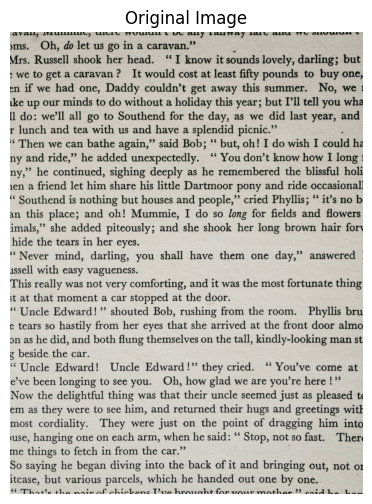

Confidence Scores (Preprocessed Image)
Text: Rea eCaeos
Confidence: 0.00
----------------------------------------
Text: Shee tr inentl iat
Confidence: 0.00
----------------------------------------
Text: Toe denne
Confidence: 0.00
----------------------------------------
Text: MaeCe e e ern e
Confidence: 0.00
----------------------------------------
Text: S
Confidence: 0.00
----------------------------------------
Text: TIn
Confidence: 0.01
----------------------------------------
Text: Lcss-
Confidence: 0.00
----------------------------------------
Text: Sosorleerosa
Confidence: 0.00
----------------------------------------
Text: 0ea  nene
Confidence: 0.00
----------------------------------------
Text: Ue
Confidence: 0.01
----------------------------------------
Text: Rs
Confidence: 0.01
----------------------------------------
Text: S0tenaese
Confidence: 0.00
----------------------------------------
Text: O
Confidence: 0.01
----------------------------------------
Text: udSa
Confidenc

In [6]:
print("Before calling function")
ocr_document("images/doc1.jpg")   
print("After calling function")

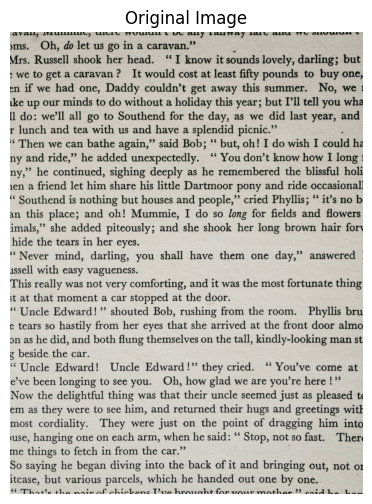

Confidence Scores (Preprocessed Image)
Text: Rea eCaeos
Confidence: 0.00
----------------------------------------
Text: Shee tr inentl iat
Confidence: 0.00
----------------------------------------
Text: Toe denne
Confidence: 0.00
----------------------------------------
Text: MaeCe e e ern e
Confidence: 0.00
----------------------------------------
Text: S
Confidence: 0.00
----------------------------------------
Text: TIn
Confidence: 0.01
----------------------------------------
Text: Lcss-
Confidence: 0.00
----------------------------------------
Text: Sosorleerosa
Confidence: 0.00
----------------------------------------
Text: 0ea  nene
Confidence: 0.00
----------------------------------------
Text: Ue
Confidence: 0.01
----------------------------------------
Text: Rs
Confidence: 0.01
----------------------------------------
Text: S0tenaese
Confidence: 0.00
----------------------------------------
Text: O
Confidence: 0.01
----------------------------------------
Text: udSa
Confidenc

In [7]:
ocr_document("images/doc1.jpg")